In [2]:
%pip install shap


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv('../data/creditcard.csv')

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Time_scaled'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))
df = df.drop(['Amount', 'Time'], axis=1)

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Load saved model
model = joblib.load('../notebooks/models/fraud_model.pkl')
print("Model loaded!")

Model loaded!


In [5]:
# Create SHAP explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values on test set
# Using a sample of 1000 rows — full dataset is slow
X_test_sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculated!")

SHAP values calculated!


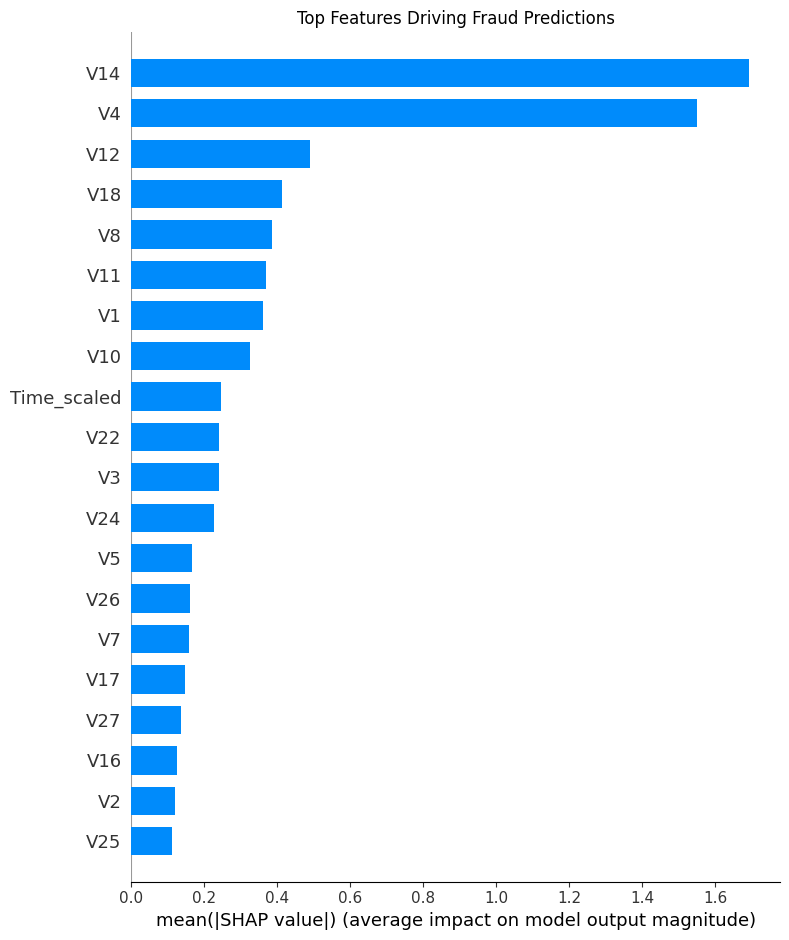

In [6]:
plt.figure()
shap.summary_plot(
    shap_values,      # fraud class
    X_test_sample,
    plot_type="bar",
    show=False
)
plt.title("Top Features Driving Fraud Predictions")
plt.tight_layout()
plt.savefig('../reports/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
print(type(shap_values))
print(len(shap_values))
print(shap_values[0].shape)
print(shap_values[1].shape)
print(shap_values.shape)

<class 'numpy.ndarray'>
1000
(30,)
(30,)
(1000, 30)


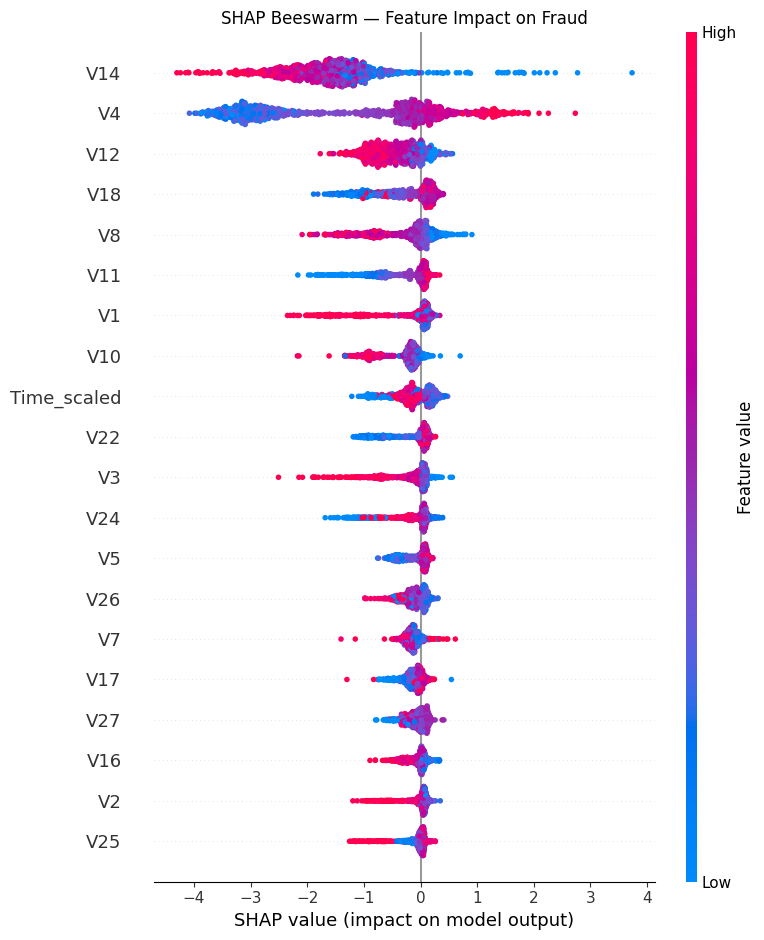

In [8]:
shap.summary_plot(
    shap_values,         
    X_test_sample,
    show=False
)
plt.title("SHAP Beeswarm — Feature Impact on Fraud")
plt.tight_layout()
plt.savefig('../reports/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

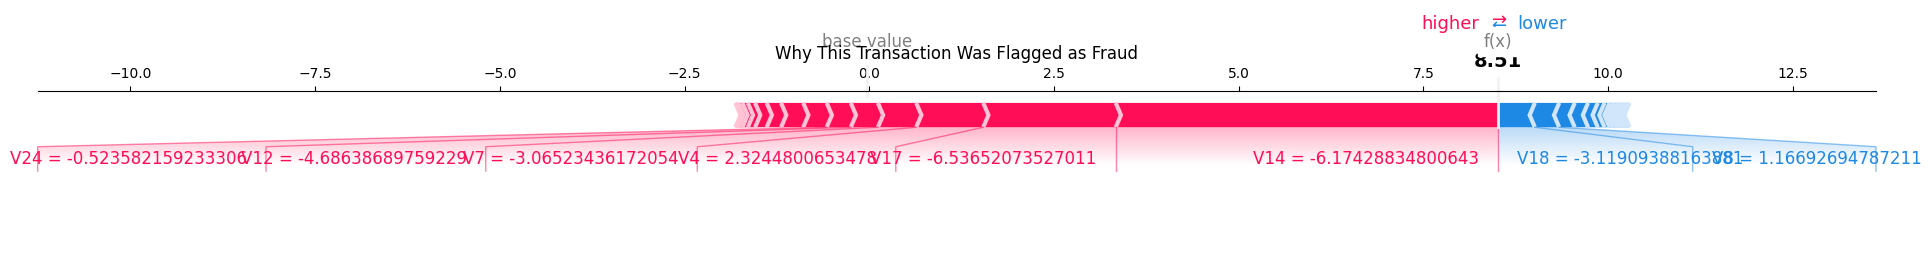

In [9]:
fraud_idx = y_test[y_test == 1].index[0]
fraud_transaction = X_test.loc[[fraud_idx]]

shap_single = explainer.shap_values(fraud_transaction)

shap.force_plot(
    explainer.expected_value,   
    shap_single[0],             
    fraud_transaction.iloc[0],
    matplotlib=True,
    show=False
)
plt.title("Why This Transaction Was Flagged as Fraud")
plt.tight_layout()
plt.savefig('../reports/shap_single.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Calculate feature importance from SHAP values
importance = np.abs(shap_values).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": X_test_sample.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

        Feature  Importance
13          V14    1.692739
3            V4    1.548635
11          V12    0.490331
17          V18    0.413388
7            V8    0.385532
10          V11    0.369880
0            V1    0.359964
9           V10    0.326043
29  Time_scaled    0.247120
21          V22    0.240186
2            V3    0.239264
23          V24    0.227254
4            V5    0.167239
25          V26    0.160207
6            V7    0.159031


In [12]:
top_features = feature_importance["Feature"].head(10).tolist()

print("Selected Features:")
top_features

Selected Features:


['V14', 'V4', 'V12', 'V18', 'V8', 'V11', 'V1', 'V10', 'Time_scaled', 'V22']

In [13]:
X_reduced = X[top_features]

print(X_reduced.shape)

(284807, 10)


In [15]:
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_train_red.shape, X_test_red.shape, y_train_red.shape, y_test_red.shape    

((227845, 10), (56962, 10), (227845,), (56962,))

In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_red_smote, y_train_red_smote = smote.fit_resample(
    X_train_red,
    y_train_red
)

print(X_train_red_smote.shape)

(454902, 10)


In [17]:
from xgboost import XGBClassifier

xgb_reduced = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='aucpr',
    n_jobs=-1
)

xgb_reduced.fit(
    X_train_red_smote,
    y_train_red_smote
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [18]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score
)

y_pred = xgb_reduced.predict(X_test_red)
y_prob = xgb_reduced.predict_proba(X_test_red)[:,1]

print(classification_report(
    y_test_red,
    y_pred
))

print(
    "ROC-AUC:",
    roc_auc_score(y_test_red, y_prob)
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test_red,
        y_prob
    )
)

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.18      0.89      0.30        98

    accuracy                           0.99     56962
   macro avg       0.59      0.94      0.65     56962
weighted avg       1.00      0.99      1.00     56962

ROC-AUC: 0.9766324843809218
PR-AUC: 0.8369068094220072


In [20]:
import joblib

joblib.dump(
    xgb_reduced,
    "../notebooks/models/fraud_model_reduced.pkl"
)

joblib.dump(
    top_features,
    "../notebooks/models/top_features.pkl"
)

print("Reduced model saved.")

Reduced model saved.


In [23]:
fraud_examples = X_test_red[y_test_red == 1]
fraud_examples.head()

,V14,V4,V12,V18,V8,V11,V1,V10,Time_scaled,V22
77348,-6.174288,2.324480,-4.686387,-3.119094,1.166927,2.255147,-1.271244,-4.881143,-0.796134,0.081931
102442,-9.072711,3.320337,-4.610756,-3.149247,-37.353443,4.406806,-13.192671,-5.052502,-0.560285,-8.887017
119781,-7.495187,3.983359,-7.128251,-4.895175,1.216655,3.048392,-2.866364,-5.515507,-0.405004,0.475840
48094,-5.208305,0.217805,-4.583096,-2.196691,0.204532,3.367361,-1.278138,-1.250286,-1.080690,0.470427
42958,-9.798012,5.581009,-10.749592,-8.153668,9.060281,5.148352,-13.897206,-14.676470,-1.126617,0.941180
